In [25]:
#!/usr/bin/env python3
"""
Plot heterogeneity + cohort results for ART venue DiD estimation.

Sections:
  1. General effect (Venice) — S, G, F
  2. Gender heterogeneity (Venice) — S, G
  3. Career stage heterogeneity (Venice) — S, G
  4. Region heterogeneity (Venice) — S, G
  5. Cohort (dynamic version) — Venice & Documenta general + gender

Reads from:
  ../../data/did_art/matched_venice_biennale/
  ../../data/did_dynamic/matched_venice_biennale/
  ../../data/did_dynamic/matched_documenta/

Saves to:
  ../../figure/heterogeneity_art/
"""

# %% ── Imports & Config ──────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'major'
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', None)

# ── Paths ──
DID_DIR = Path('../../data/did_art')
DID_DYN_DIR = Path('../../data/did_dynamic')
FIG_DIR = Path('../../figure/heterogeneity_art')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Default venue for event-study heterogeneity ──
VENUE = 'matched_venice_biennale_enriched_titles'
VENUE = 'matched_venice_biennale'
DATA_DIR = DID_DIR / VENUE

# ── Palettes ──
COLOR_FEMALE = '#C8A2C8'
COLOR_MALE   = '#6FA8DC'

In [26]:
import os
# When was the file last modified?
path = '../../data/matches/matched_venice_biennale.csv'
mod_time = os.path.getmtime(path)
import datetime
print(f"Last modified: {datetime.datetime.fromtimestamp(mod_time)}")
print(f"Size: {os.path.getsize(path):,} bytes")

Last modified: 2026-03-22 15:52:03.916373
Size: 11,799,346 bytes


Data dir (event-study): ../../data/did_art
Data dir (dynamic):     ../../data/did_dynamic
Figure dir:             ../../figure/heterogeneity_art

── General Effect ──
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles.csv
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_general_effect.png
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_general_effect.pdf


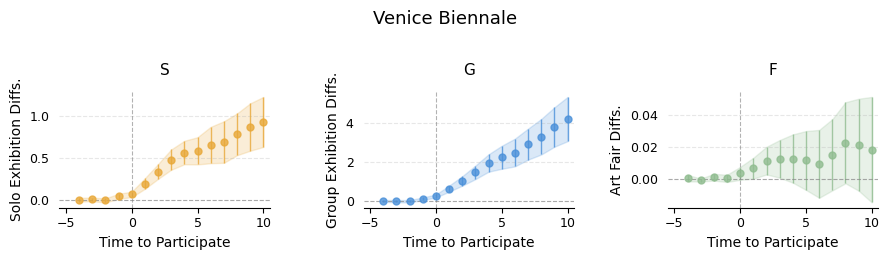


── Gender ──
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_gender_female.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_gender_male.csv
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_gender_heterogeneity.png
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_gender_heterogeneity.pdf


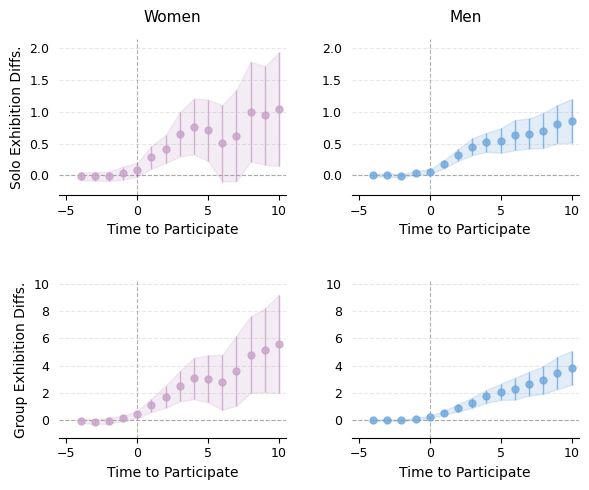


── Career Stage ──
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_career_early-career.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_career_mid-career.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_career_late-career.csv
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_career_heterogeneity.png
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_career_heterogeneity.pdf


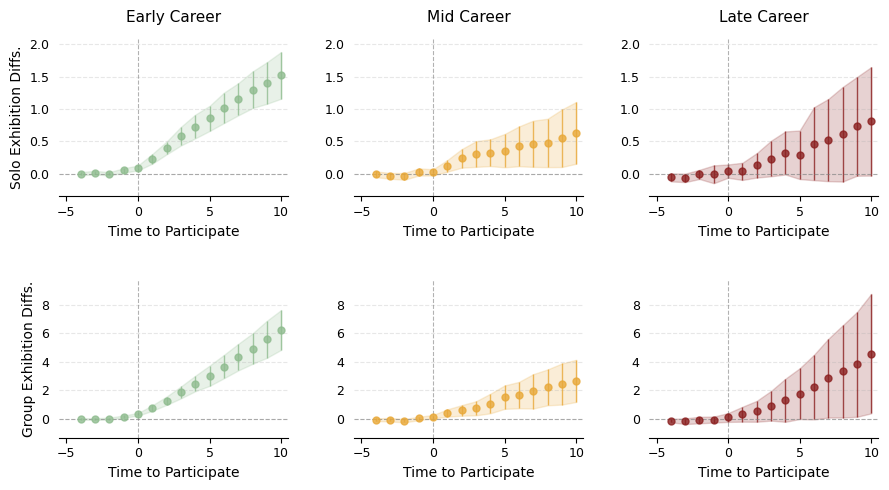


── Region ──
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_region_Europe.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_region_NorthAmerica.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_region_Asia.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_region_SouthAmerica.csv
  [skip] ../../data/did_art/matched_venice_biennale/dynamic_S_titles_region_Africa.csv
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_region_heterogeneity.png
  Saved: ../../figure/heterogeneity_art/matched_venice_biennale_region_heterogeneity.pdf


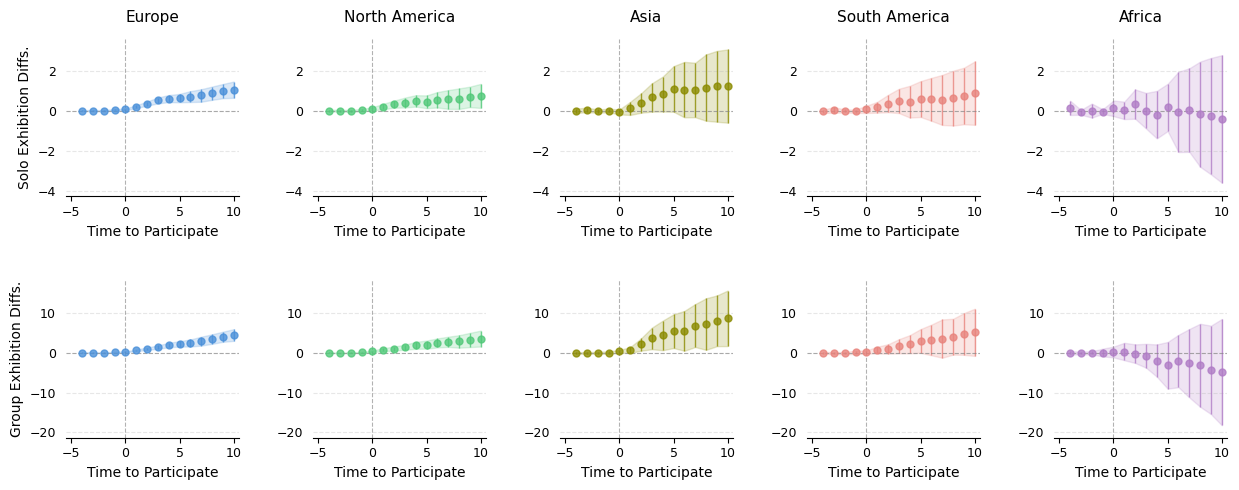

  -> matched_venice_biennale_enriched_titles_cohort_general_S.pdf
  -> matched_venice_biennale_enriched_titles_cohort_general_S.png


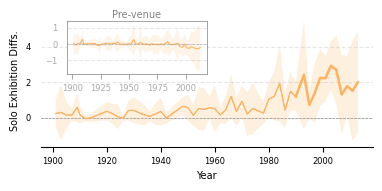

  -> matched_venice_biennale_enriched_titles_cohort_general_G.pdf
  -> matched_venice_biennale_enriched_titles_cohort_general_G.png


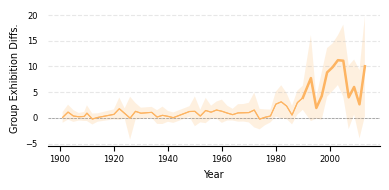

  -> matched_documenta_enriched_titles_cohort_general_S.pdf
  -> matched_documenta_enriched_titles_cohort_general_S.png


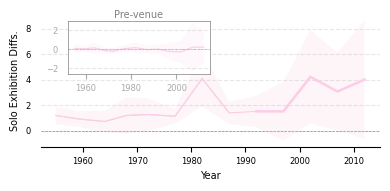

  -> matched_documenta_enriched_titles_cohort_general_G.pdf
  -> matched_documenta_enriched_titles_cohort_general_G.png


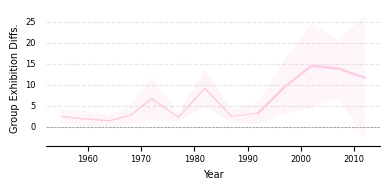


── Cohort: Gender (Venice) ──

── Cohort: Gender (Venice + Documenta) ──

── Cohort: Combined (Venice + Documenta) ──
  -> combined_cohort_general_S.pdf
  -> combined_cohort_general_S.png


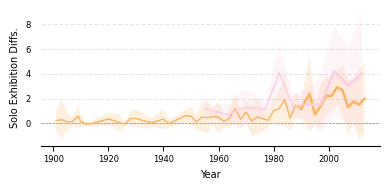

  -> combined_cohort_general_G.pdf
  -> combined_cohort_general_G.png


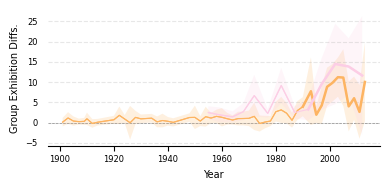


── Cohort: Gender per venue ──

── Cohort: General (per venue) ──

Done!


In [27]:
#!/usr/bin/env python3
"""
Plot heterogeneity + cohort results for ART venue DiD estimation.

Sections:
  1. General effect (Venice) — S, G, F  (S has S_titles inset)
  2. Gender heterogeneity (Venice) — S, G  (S row has S_titles inset)
  3. Career stage heterogeneity (Venice) — S, G  (S row has S_titles inset)
  4. Region heterogeneity (Venice) — S, G  (S row has S_titles inset)
  5. Cohort (dynamic version) — Venice & Documenta general + gender
  6. Cohort: S_titles (pre-venue title reuse) standalone + overlaid

Reads from:
  ../../data/did_art/matched_venice_biennale_enriched_titles/
  ../../data/did_dynamic/matched_venice_biennale/
  ../../data/did_dynamic/matched_documenta/

Saves to:
  ../../figure/heterogeneity_art/
"""

# %% ── Imports & Config ──────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'major'
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3


# ── Paths ──
DID_DIR     = Path('../../data/did_art')
DID_DYN_DIR = Path('../../data/did_dynamic')
FIG_DIR     = Path('../../figure/heterogeneity_art')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Default venue for event-study heterogeneity ──
# VENUE    = 'matched_venice_biennale_enriched_titles'
VENUE = 'matched_venice_biennale'
DATA_DIR = DID_DIR / VENUE

# ── Palettes ──
COLOR_FEMALE = '#C8A2C8'
COLOR_MALE   = '#6FA8DC'

genders = [
    ('female', 'Women',  COLOR_FEMALE),
    ('male',   'Men',    COLOR_MALE),
]

stages = [
    ('early-career', 'Early Career', '#8FBC8F'),
    ('mid-career',   'Mid Career',   '#E8A838'),
    ('late-career',  'Late Career',  '#8B2020'),
]

regions = [
    ('Europe',        'Europe',         '#4A90D9'),
    ('NorthAmerica',  'North America',  '#50C878'),
    ('Asia',          'Asia',           '#8B8B00'),
    ('SouthAmerica',  'South America',  '#E8837C'),
    ('Africa',        'Africa',         '#B07CC6'),
]

# ── Cohort config ──
SET3 = plt.cm.Set3.colors
VENUES_DYN = [
    ('matched_venice_biennale_enriched_titles', 'Venice Biennale', SET3[5]),
    ('matched_documenta_enriched_titles',       'Documenta',       SET3[7]),
]

ALPHA_FILL       = 0.20
ALPHA_FILL_INSET = 0.15
FIGSIZE          = (4, 2)
MIN_YEAR         = 1900

# ── Inset outcome: S_titles (pre-venue title reuse) ──
# This is the art analogue of cum_citations_old in science.
INSET_OUTCOME = 'S_titles'


# %% ── I/O helpers ───────────────────────────────────────────────────────────

def load_dynamic(filename, data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR
    fpath = Path(data_dir) / filename
    if not fpath.exists():
        print(f'  [skip] {fpath}')
        return pd.DataFrame()
    df = pd.read_csv(fpath)
    if 'event_time' not in df.columns and 'to_year' in df.columns:
        df['event_time'] = df['to_year']
    return df.sort_values('event_time').reset_index(drop=True)


def load_cohort(metric, venue_dir, suffix=''):
    fname = f'cohort_{metric}{suffix}.csv'
    fpath = DID_DYN_DIR / venue_dir / fname
    if not fpath.exists():
        print(f'  [skip] {fpath}')
        return pd.DataFrame()
    df = pd.read_csv(fpath).sort_values('group').reset_index(drop=True)
    df = df[df['group'] >= MIN_YEAR]
    return df.copy()


# %% ── Core plotting ────────────────────────────────────────────────────────

def plot_att(ax, df, color, label=None, alpha_fill=0.2, alpha_line=0.8,
             marker='o', markersize=5, linewidth=1.5):
    if df.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', fontsize=10, color='gray')
        return
    e      = df['event_time'].values
    att    = df['att'].values
    ci_lo  = df['ci_lower'].values
    ci_hi  = df['ci_upper'].values
    se     = df['se'].values

    ax.fill_between(e, ci_lo, ci_hi, color=color, alpha=alpha_fill)
    ax.errorbar(e, att, yerr=1.96 * se, fmt=marker, color=color,
                markersize=markersize, linewidth=linewidth,
                capsize=0, alpha=alpha_line, label=label,
                markeredgecolor=color, markerfacecolor=color, elinewidth=1.0)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)


def plot_att_inset(ax_inset, df, color, alpha_fill=0.15, alpha_line=0.7,
                   marker='o', markersize=3, linewidth=1.0):
    """Plot ATT on an inset axis (smaller markers, thinner lines)."""
    if df.empty:
        return
    e     = df['event_time'].values
    att   = df['att'].values
    ci_lo = df['ci_lower'].values
    ci_hi = df['ci_upper'].values
    se    = df['se'].values

    ax_inset.fill_between(e, ci_lo, ci_hi, color=color, alpha=alpha_fill)
    ax_inset.errorbar(e, att, yerr=1.96 * se, fmt=marker, color=color,
                      markersize=markersize, linewidth=linewidth,
                      capsize=0, alpha=alpha_line,
                      markeredgecolor=color, markerfacecolor=color,
                      elinewidth=0.7)
    ax_inset.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax_inset.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)


def style_ax(ax, title='', ylabel='', xlabel='Time to Participate'):
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='normal', pad=12)
    ax.tick_params(labelsize=9)
    ax.set_xlim(-5.5, 10.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def sync_ylim_row(axes_row):
    ymins, ymaxs = [], []
    for ax in axes_row:
        ylo, yhi = ax.get_ylim()
        if len(ax.lines) > 0 or len(ax.collections) > 0:
            ymins.append(ylo)
            ymaxs.append(yhi)
    if ymins and ymaxs:
        lo = min(ymins)
        hi = max(ymaxs)
        pad = (hi - lo) * 0.05
        for ax in axes_row:
            ax.set_ylim(lo - pad, hi + pad)


def add_inset(ax, df_inset, color, inset_title='Pre-venue',
              bounds=[0.08, 0.55, 0.42, 0.40]):
    """
    Add an inset plot (S_titles / pre-venue title reuse) inside the main axes.
    Mirrors the science version's cum_citations_old inset.
    """
    if df_inset.empty:
        return None

    ax_ins = ax.inset_axes(bounds)
    plot_att_inset(ax_ins, df_inset, color=color)
    ax_ins.set_xlim(-5.5, 10.5)
    ax_ins.tick_params(axis='both', labelsize=6, colors='darkgray')
    ax_ins.set_title(inset_title, fontsize=7, pad=2, color='gray')

    for spine in ax_ins.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('gray')
    ax_ins.set_facecolor('white')
    ax_ins.patch.set_alpha(1.0)

    return ax_ins


def save_fig(fig, stem):
    fig.tight_layout(w_pad=2.5, h_pad=3.0)
    fig.patch.set_alpha(1)
    for ax in fig.get_axes():
        ax.patch.set_alpha(1)
    for ext in ['png', 'pdf']:
        out = FIG_DIR / f'{stem}.{ext}'
        fig.savefig(out, dpi=300, bbox_inches='tight', transparent=False)
        print(f'  Saved: {out}')
    plt.show()
    plt.close(fig)


# %% ── Cohort helpers ────────────────────────────────────────────────────────

def draw_cohort(ax, df, color, lw=1.3):
    x  = df['group'].values
    y  = df['att'].values
    se = df['se'].values
    lo = y - 1.96 * se
    hi = y + 1.96 * se
    ax.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL, edgecolor='none')
    ax.plot(x, y, color=color, linewidth=lw)

def draw_cohort(ax, df, color, lw=1.3, solid_after=1990):
    x  = df['group'].values
    y  = df['att'].values
    se = df['se'].values
    lo = y - 1.96 * se
    hi = y + 1.96 * se
    ax.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL, edgecolor='none')
    ax.plot(x, y, color=color,
            linewidth=lw-0.5, linestyle='-')
    if solid_after is not None:
        mask_dash  = x <= solid_after
        mask_solid = x >= solid_after
        if mask_dash.any():
            ax.plot(x[mask_dash], y[mask_dash], color=color,
                    linewidth=lw-0.5, linestyle='-')
        if mask_solid.any():
            ax.plot(x[mask_solid], y[mask_solid], color=color,
                    linewidth=lw+0.5, linestyle='-')
    else:
        ax.plot(x, y, color=color, linewidth=lw)


def style_cohort(ax, ylabel='', xlabel='Year'):
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', zorder=0)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def add_cohort_inset(ax, df_inset, color, inset_title='Pre-venue',
                     bounds=[0.08, 0.55, 0.42, 0.40]):
    """Add an inset to a cohort axis (uses group/att/se columns)."""
    if df_inset.empty:
        return None

    ins = ax.inset_axes(bounds)
    x  = df_inset['group'].values
    y  = df_inset['att'].values
    se = df_inset['se'].values
    lo = y - 1.96 * se
    hi = y + 1.96 * se

    ins.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL_INSET,
                     edgecolor='none')
    ins.plot(x, y, color=color, linewidth=0.8)
    ins.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ins.tick_params(axis='both', labelsize=6, colors='darkgray')
    ins.set_title(inset_title, fontsize=7, pad=2, color='gray')

    for spine in ins.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('gray')

    return ins


def save_cohort(fig, stem):
    fig.tight_layout()
    for ext in ['pdf', 'png']:
        out = FIG_DIR / f'{stem}.{ext}'
        fig.savefig(out, dpi=600, bbox_inches='tight')
        print(f'  -> {out.name}')
    plt.show()
    plt.close(fig)


# %% ── 1. GENERAL EFFECT (Venice) ───────────────────────────────────────────
# 1 row × 3 cols: S (with S_titles inset), G, F

def plot_general(venue=VENUE, save=True):
    data_dir = DID_DIR / venue

    outcomes = [
        ('S', 'Solo Exhibition Diffs.', '#E8A838'),
        ('G', 'Group Exhibition Diffs.', '#4A90D9'),
        ('F', 'Art Fair Diffs.',         '#8FBC8F'),
    ]

    ncols = len(outcomes)
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 2.5), squeeze=False)

    for col, (outcome, ylabel, color) in enumerate(outcomes):
        ax = axes[0, col]
        fname = f'dynamic_{outcome}.csv'
        df = load_dynamic(fname, data_dir)
        plot_att(ax, df, color=color)
        style_ax(ax, title=outcome, ylabel=ylabel)

        # Add S_titles inset for the S outcome
        if outcome == 'S':
            fname_inset = f'dynamic_{INSET_OUTCOME}.csv'
            df_inset = load_dynamic(fname_inset, data_dir)
            add_inset(ax, df_inset, color=color,
                      inset_title='Pre-venue')

    fig.suptitle(venue.replace('matched_', '').replace('_', ' ').title(),
                 fontsize=13, y=1.02)

    if save:
        save_fig(fig, f'{venue}_general_effect')
    return fig


# %% ── 2. GENDER HETEROGENEITY (Venice) ─────────────────────────────────────
# 2 rows (S, G) × 2 cols (Women, Men)
# S row has S_titles inset per gender

def plot_gender(venue=VENUE, save=True):
    data_dir = DID_DIR / venue

    main_outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    nrows = len(main_outcomes)
    ncols = len(genders)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3 * ncols, 2.5 * nrows), squeeze=False)

    for row, (outcome, ylabel) in enumerate(main_outcomes):
        for col, (gval, glabel, gcolor) in enumerate(genders):
            ax = axes[row, col]
            fname = f'dynamic_{outcome}_gender_{gval}.csv'
            df = load_dynamic(fname, data_dir)
            plot_att(ax, df, color=gcolor)

            ylabel_show = ylabel if col == 0 else ''
            style_ax(ax, title=glabel if row == 0 else '', ylabel=ylabel_show)

            # Inset: S_titles for S row
            if outcome == 'S':
                fname_inset = f'dynamic_{INSET_OUTCOME}_gender_{gval}.csv'
                df_inset = load_dynamic(fname_inset, data_dir)
                add_inset(ax, df_inset, color=gcolor,
                          inset_title='Pre-venue')

        sync_ylim_row(axes[row, :])

    if save:
        save_fig(fig, f'{venue}_gender_heterogeneity')
    return fig


# %% ── 3. CAREER STAGE HETEROGENEITY (Venice) ───────────────────────────────
# 2 rows (S, G) × 3 cols (Early, Mid, Late)
# S row has S_titles inset per career stage

def plot_career(venue=VENUE, save=True):
    data_dir = DID_DIR / venue

    main_outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    nrows = len(main_outcomes)
    ncols = len(stages)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3 * ncols, 2.5 * nrows), squeeze=False)

    for row, (outcome, ylabel) in enumerate(main_outcomes):
        for col, (cval, clabel, ccolor) in enumerate(stages):
            ax = axes[row, col]
            fname = f'dynamic_{outcome}_career_{cval}.csv'
            df = load_dynamic(fname, data_dir)
            plot_att(ax, df, color=ccolor)

            ylabel_show = ylabel if col == 0 else ''
            style_ax(ax, title=clabel if row == 0 else '', ylabel=ylabel_show)

            if outcome == 'S':
                fname_inset = f'dynamic_{INSET_OUTCOME}_career_{cval}.csv'
                df_inset = load_dynamic(fname_inset, data_dir)
                add_inset(ax, df_inset, color=ccolor,
                          inset_title='Pre-venue')

        sync_ylim_row(axes[row, :])

    if save:
        save_fig(fig, f'{venue}_career_heterogeneity')
    return fig


# %% ── 4. REGION HETEROGENEITY (Venice) ──────────────────────────────────────
# 2 rows (S, G) × N cols (available regions)
# S row has S_titles inset per region

def plot_region(venue=VENUE, save=True):
    data_dir = DID_DIR / venue

    main_outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    available = []
    for rsuffix, rlabel, rcolor in regions:
        for outcome, _ in main_outcomes:
            if (data_dir / f'dynamic_{outcome}_region_{rsuffix}.csv').exists():
                available.append((rsuffix, rlabel, rcolor))
                break

    if not available:
        print('  No region data found!')
        return None

    ncols = len(available)
    nrows = len(main_outcomes)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(2.5 * ncols, 2.5 * nrows), squeeze=False)

    for row, (outcome, ylabel) in enumerate(main_outcomes):
        for col, (rsuffix, rlabel, rcolor) in enumerate(available):
            ax = axes[row, col]
            fname = f'dynamic_{outcome}_region_{rsuffix}.csv'
            df = load_dynamic(fname, data_dir)
            plot_att(ax, df, color=rcolor)

            ylabel_show = ylabel if col == 0 else ''
            style_ax(ax, title=rlabel if row == 0 else '', ylabel=ylabel_show)

            if outcome == 'S':
                fname_inset = f'dynamic_{INSET_OUTCOME}_region_{rsuffix}.csv'
                df_inset = load_dynamic(fname_inset, data_dir)
                add_inset(ax, df_inset, color=rcolor,
                          inset_title='Pre-venue')

        sync_ylim_row(axes[row, :])

    if save:
        save_fig(fig, f'{venue}_region_heterogeneity')
    return fig


# %% ── 5. COHORT PLOTS (Dynamic version) ────────────────────────────────────

# ── Stata dynamic dir ──
DID_DYN_STATA_DIR = Path('../../data/did_dynamic')
COHORT_DIRS = [DID_DYN_STATA_DIR, DID_DYN_DIR]


def load_cohort_multi(metric, venue_dir, suffix=''):
    """Load cohort CSV, trying Stata dir first, then Python csdid dir."""
    fname = f'cohort_{metric}{suffix}.csv'
    for base_dir in COHORT_DIRS:
        fpath = base_dir / venue_dir / fname
        if fpath.exists():
            df = pd.read_csv(fpath)
            if 'group' not in df.columns and 'term' in df.columns:
                df['group'] = df['term'].str.replace('t', '', regex=False).astype(float)
            if 'group' not in df.columns:
                print(f'  [skip] No group column in {fpath}')
                return pd.DataFrame()
            df = df.sort_values('group').reset_index(drop=True)
            df = df[df['group'] >= MIN_YEAR]
            return df.copy()
    return pd.DataFrame()


def load_dynamic_multi(metric, venue_dir, suffix=''):
    """Load dynamic CSV, trying Stata dir first, then Python csdid dir."""
    fname = f'dynamic_{metric}{suffix}.csv'
    for base_dir in COHORT_DIRS:
        fpath = base_dir / venue_dir / fname
        if fpath.exists():
            df = pd.read_csv(fpath)
            if 'event_time' not in df.columns and 'term' in df.columns:
                def parse_et(t):
                    t = str(t)
                    if t.startswith('tp'):
                        return int(t.replace('tp', ''))
                    elif t.startswith('tm'):
                        return -int(t.replace('tm', ''))
                    return None
                df['event_time'] = df['term'].apply(parse_et)
            if 'event_time' not in df.columns and 'to_year' in df.columns:
                df['event_time'] = df['to_year']
            df = df.dropna(subset=['event_time'])
            df['event_time'] = df['event_time'].astype(int)
            return df.sort_values('event_time').reset_index(drop=True)
    return pd.DataFrame()


def plot_cohort_general():
    """General cohort: S and G for each venue, with S_titles inset on S."""
    outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    for venue_dir, vlabel, vcolor in VENUES_DYN:
        for metric, ylabel in outcomes:
            df = load_cohort_multi(metric, venue_dir)
            if df.empty:
                continue

            fig, ax = plt.subplots(figsize=FIGSIZE)
            draw_cohort(ax, df, vcolor)
            style_cohort(ax, ylabel=ylabel)

            # S_titles inset for solo exhibition cohort
            if metric == 'S':
                df_inset = load_cohort_multi('S_titles', venue_dir)
                if not df_inset.empty:
                    add_cohort_inset(ax, df_inset, vcolor,
                                     inset_title='Pre-venue')

            save_cohort(fig, f'{venue_dir}_cohort_general_{metric}')


def plot_cohort_gender():
    """Gender cohort: Venice only, S and G, with S_titles inset on S."""
    venue_dir = 'matched_venice_biennale'
    outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    for metric, ylabel in outcomes:
        dfs = {}
        for gsuf, glabel, gcolor in genders:
            dfs[gsuf] = load_cohort_multi(metric, venue_dir, f'_gender_{gsuf}')

        if all(d.empty for d in dfs.values()):
            continue

        fig, ax = plt.subplots(figsize=FIGSIZE)
        for gsuf, glabel, gcolor in genders:
            if not dfs[gsuf].empty:
                draw_cohort(ax, dfs[gsuf], gcolor)

        style_cohort(ax, ylabel=ylabel)

        # S_titles inset for S metric by gender
        if metric == 'S':
            ins = None
            for gsuf, glabel, gcolor in genders:
                df_inset = load_cohort_multi('S_titles', venue_dir,
                                             f'_gender_{gsuf}')
                if df_inset.empty:
                    continue
                if ins is None:
                    ins = add_cohort_inset(ax, df_inset, gcolor,
                                           inset_title='Pre-venue')
                else:
                    x  = df_inset['group'].values
                    y  = df_inset['att'].values
                    se = df_inset['se'].values
                    lo = y - 1.96 * se
                    hi = y + 1.96 * se
                    ins.fill_between(x, lo, hi, color=gcolor,
                                     alpha=ALPHA_FILL_INSET, edgecolor='none')
                    ins.plot(x, y, color=gcolor, linewidth=0.8)

        save_cohort(fig, f'{venue_dir}_cohort_gender_{metric}')

        
def plot_combined_cohort():
    """Venice + Documenta overlaid: S and G, with S_titles inset on S."""
    outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    for metric, ylabel in outcomes:
        fig, ax = plt.subplots(figsize=(4, 2))

        for venue_dir, vlabel, vcolor in VENUES_DYN:
            df = load_cohort_multi(metric, venue_dir)
            if not df.empty:
                draw_cohort(ax, df, vcolor)

        style_cohort(ax, ylabel=ylabel)

        # # S_titles inset for S, overlaid across venues
        # if metric == 'S':
        #     ins = None
        #     for venue_dir, vlabel, vcolor in VENUES_DYN:
        #         df_inset = load_cohort_multi('S_titles', venue_dir)
        #         if df_inset.empty:
        #             continue
        #         if ins is None:
        #             ins = add_cohort_inset(ax, df_inset, vcolor,
        #                                    inset_title='Pre-venue')
        #         else:
        #             x  = df_inset['group'].values
        #             y  = df_inset['att'].values
        #             se = df_inset['se'].values
        #             lo = y - 1.96 * se
        #             hi = y + 1.96 * se
        #             ins.fill_between(x, lo, hi, color=vcolor,
        #                              alpha=ALPHA_FILL_INSET, edgecolor='none')
        #             ins.plot(x, y, color=vcolor, linewidth=0.8)

        save_cohort(fig, f'combined_cohort_general_{metric}')


# %% ── 6. GENDER COHORT: Venice + Documenta combined ────────────────────────

def plot_gender_cohort_combined(save=True):
    """Gender cohort: S and G, Venice + Documenta overlaid per gender."""
    outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    venue_styles = {
        'matched_venice_biennale': {'ls': '-',  'lw': 1.3},
        'matched_documenta':       {'ls': '--', 'lw': 1.0},
    }

    for metric, ylabel in outcomes:
        fig, ax = plt.subplots(figsize=FIGSIZE)

        has_data = False
        for venue_dir, vlabel, _ in VENUES_DYN:
            vstyle = venue_styles.get(venue_dir, {'ls': '-', 'lw': 1.0})
            for gsuf, glabel, gcolor in genders:
                df = load_cohort_multi(metric, venue_dir, f'_{gsuf}')
                if df.empty:
                    continue
                has_data = True
                x  = df['group'].values
                y  = df['att'].values
                se = df['se'].values
                lo = y - 1.96 * se
                hi = y + 1.96 * se
                ax.fill_between(x, lo, hi, color=gcolor,
                                alpha=ALPHA_FILL * 0.6, edgecolor='none')
                ax.plot(x, y, color=gcolor,
                        linewidth=vstyle['lw'], linestyle=vstyle['ls'])

        if not has_data:
            plt.close(fig)
            continue

        style_cohort(ax, ylabel=ylabel)

        # # S_titles inset for S, overlaid by gender and venue
        # if metric == 'S':
        #     ins = None
        #     for venue_dir, vlabel, _ in VENUES_DYN:
        #         vstyle = venue_styles.get(venue_dir, {'ls': '-', 'lw': 0.8})
        #         for gsuf, glabel, gcolor in genders:
        #             df_inset = load_cohort_multi('S_titles', venue_dir,
        #                                          f'_{gsuf}')
        #             if df_inset.empty:
        #                 continue
        #             if ins is None:
        #                 ins = add_cohort_inset(ax, df_inset, gcolor,
        #                                        inset_title='Pre-venue')
        #             else:
        #                 x  = df_inset['group'].values
        #                 y  = df_inset['att'].values
        #                 se = df_inset['se'].values
        #                 lo = y - 1.96 * se
        #                 hi = y + 1.96 * se
        #                 ins.fill_between(x, lo, hi, color=gcolor,
        #                                  alpha=ALPHA_FILL_INSET,
        #                                  edgecolor='none')
        #                 ins.plot(x, y, color=gcolor,
        #                          linewidth=vstyle['lw'] * 0.6,
        #                          linestyle=vstyle['ls'])

        if save:
            save_cohort(fig, f'combined_cohort_gender_{metric}')


def plot_gender_cohort_per_venue(save=True):
    """Gender cohort per venue, with S_titles inset on S."""
    outcomes = [
        ('S', 'Solo Exhibition Diffs.'),
        ('G', 'Group Exhibition Diffs.'),
    ]

    for venue_dir, vlabel, _ in VENUES_DYN:
        for metric, ylabel in outcomes:
            dfs = {}
            for gsuf, glabel, gcolor in genders:
                dfs[gsuf] = load_cohort_multi(metric, venue_dir,
                                              f'_gender_{gsuf}')

            if all(d.empty for d in dfs.values()):
                continue

            fig, ax = plt.subplots(figsize=FIGSIZE)
            for gsuf, glabel, gcolor in genders:
                if not dfs[gsuf].empty:
                    draw_cohort(ax, dfs[gsuf], gcolor)

            style_cohort(ax, ylabel=ylabel)

            # if metric == 'S':
            #     ins = None
            #     for gsuf, glabel, gcolor in genders:
            #         df_inset = load_cohort_multi('S_titles', venue_dir,
            #                                      f'_gender_{gsuf}')
            #         if df_inset.empty:
            #             continue
            #         if ins is None:
            #             ins = add_cohort_inset(ax, df_inset, gcolor,
            #                                    inset_title='Pre-venue')
            #         else:
            #             x  = df_inset['group'].values
            #             y  = df_inset['att'].values
            #             se = df_inset['se'].values
            #             lo = y - 1.96 * se
            #             hi = y + 1.96 * se
            #             ins.fill_between(x, lo, hi, color=gcolor,
            #                              alpha=ALPHA_FILL_INSET,
            #                              edgecolor='none')
            #             ins.plot(x, y, color=gcolor, linewidth=0.8)

            if save:
                save_cohort(fig, f'{venue_dir}_cohort_gender_{metric}')
# %% ── Run all ───────────────────────────────────────────────────────────────

if __name__ == '__main__':
    print(f'Data dir (event-study): {DID_DIR}')
    print(f'Data dir (dynamic):     {DID_DYN_DIR}')
    print(f'Figure dir:             {FIG_DIR}\n')

    # ── Event-study heterogeneity (Venice) ──
    print('── General Effect ──')
    plot_general()

    print('\n── Gender ──')
    plot_gender()

    print('\n── Career Stage ──')
    plot_career()

    print('\n── Region ──')
    plot_region()
    plot_cohort_general()

    print('\n── Cohort: Gender (Venice) ──')
    plot_cohort_gender()

    print('\n── Cohort: Gender (Venice + Documenta) ──')
    plot_gender_cohort_combined()

    print('\n── Cohort: Combined (Venice + Documenta) ──')
    plot_combined_cohort()

    print('\n── Cohort: Gender per venue ──')
    plot_gender_cohort_per_venue()
    # ── Cohort (dynamic version) ──
    print('\n── Cohort: General (per venue) ──')

    print('\nDone!')

In [ ]:
DID_DIR     = Path('../../data/did_art')
DID_DYN_DIR = Path('../../data/did_dynamic')
FIG_DIR     = Path('../../figure/heterogeneity_art')
FIG_DIR.mkdir(parents=True, exist_ok=True)


Saved art to ../../figure


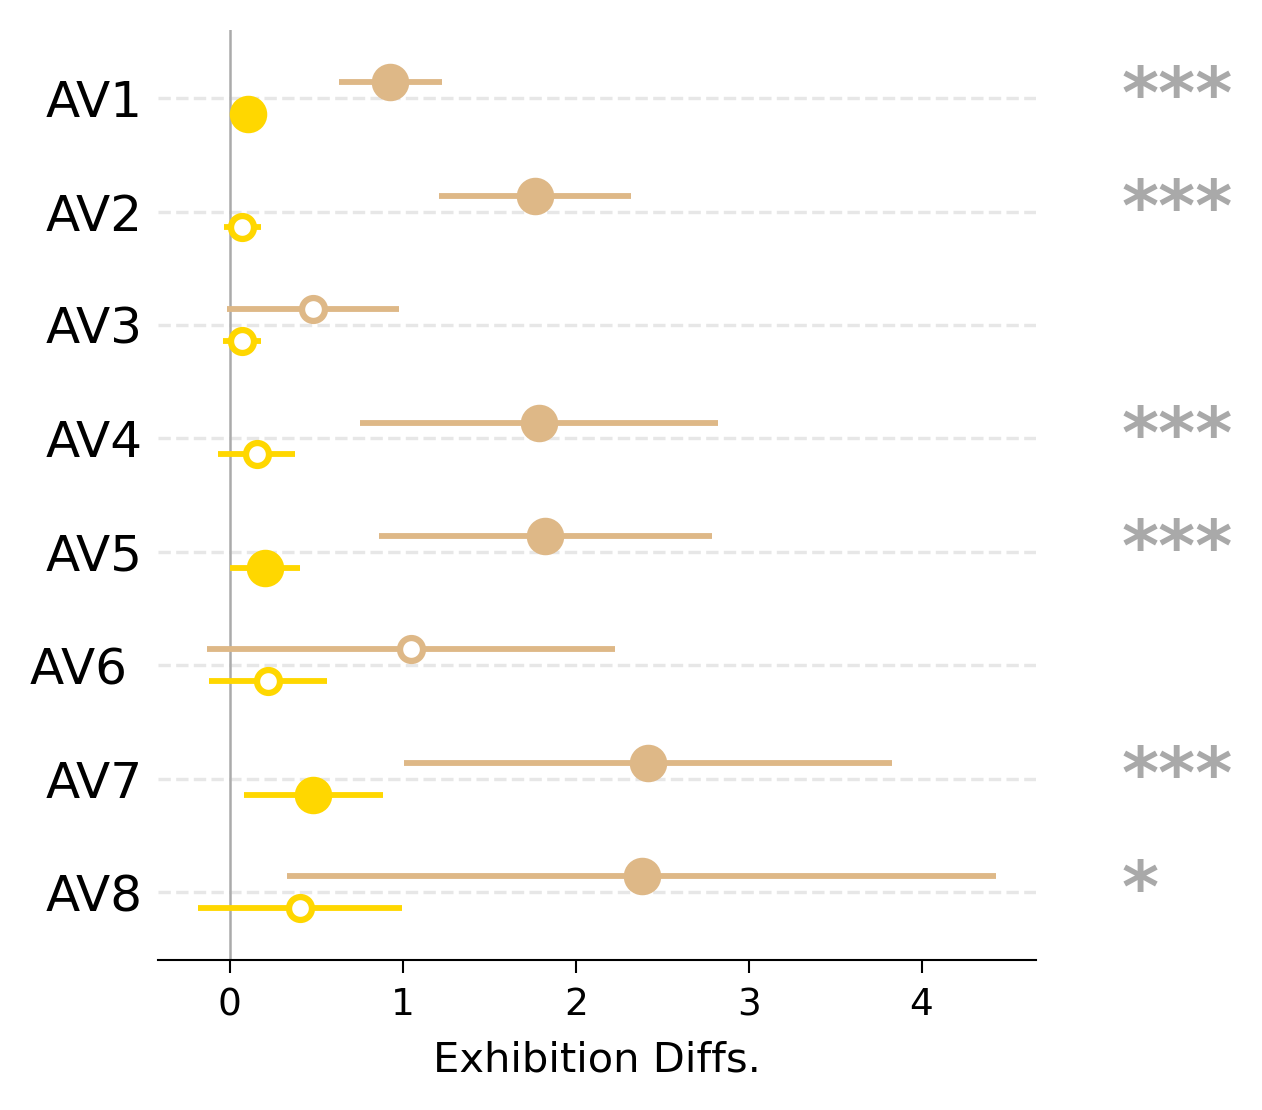


Art plot values:
label   series   att    se  ci_lower  ci_upper  pvalue stars
  AV1        S 0.928 0.152     0.629     1.227   0.000   ***
  AV1 S_titles 0.106 0.034     0.040     0.173   0.002    **
  AV2        S 1.765 0.283     1.211     2.320   0.000   ***
  AV2 S_titles 0.072 0.055    -0.036     0.181   0.190      
  AV3        S 0.479 0.253    -0.018     0.976   0.059      
  AV3 S_titles 0.069 0.056    -0.040     0.178   0.215      
  AV4        S 1.787 0.528     0.753     2.820   0.001   ***
  AV4 S_titles 0.157 0.114    -0.066     0.380   0.168      
  AV5        S 1.825 0.491     0.863     2.788   0.000   ***
  AV5 S_titles 0.205 0.104     0.001     0.409   0.049     *
 AV6         S 1.046 0.601    -0.133     2.224   0.082      
 AV6  S_titles 0.222 0.174    -0.119     0.563   0.202      
  AV7        S 2.418 0.720     1.006     3.831   0.001   ***
  AV7 S_titles 0.484 0.206     0.080     0.888   0.019     *
  AV8        S 2.381 1.047     0.329     4.433   0.023     *
  AV8 

In [5]:
#!/usr/bin/env python3
"""
Venue Effect — Horizontal Errorbar Plot (Science + Art)
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# =============================================================================
# *** CHANGE THESE ***
# =============================================================================

EVENT_TIME = 10              # <-- change to 10 for 10-year ATT
SAVE_FIGS  = True
OUTPUT_DIR = '../../figure'

# =============================================================================
# SCIENCE config
# =============================================================================

SCI_DID_BASE = Path('../../data/did')

SCI_VENUES = [
    ('merged_physics_Nature_l2',          'SV1 (Physics)',    False),
    ('merged_physics_Science_l2',         'SV2 (Physics)',    False),
    ('merged_physics_PNAS_l2',            'SV3 (Physics)',    False),
    ('merged_physics_PRL_l2',             'SV4 (Physics)',    True),
    ('merged_physics_PRA_l2',             'SV5 (Physics)',    True),
    ('merged_physics_PRB_l2',             'SV6 (Physics)',    True),
    ('merged_physics_PRC_l2',             'SV7 (Physics)',    True),
    ('merged_chemistry_Nature_l2',           'SV1 (Chemistry)', False),
    ('merged_chemistry_Science_l2',          'SV2 (Chemistry)', False),
    ('merged_chemistry_PNAS_l2',             'SV3 (Chemistry)', False),
    ('merged_biology_Nature_l2',   'SV1 (Biology)',   False),
    ('merged_biology_Science_l2',  'SV2 (Biology)',   False),
    ('merged_biology_PNAS_l2',     'SV3 (Biology)',   False),
    ('merged_biology_Cell_l2',     'SV4 (Biology)',   False),
    ('merged_sociology_ASR_l2',              'SSV1 (Sociology)', False),
    ('merged_sociology_Ann_Rev_Sociology_l2','SSV2 (Sociology)', False),
    ('merged_sociology_ESR_l2',              'SSV3 (Sociology)', False),
]

SCI_DISCIPLINE_GROUPS = {
    'Physics':    (0, 7),
    'Chemistry':  (7, 10),
    'Biology':    (10, 14),
    'Sociology':  (14, 17),
}

SCI_OUTCOMES = ['cum_citations_na', 'cum_citations_old']
SCI_COLORS = {
    'cum_citations_na':  '#2D8C5A',
    'cum_citations_old': 'palegreen',
}

# =============================================================================
# ART config
# =============================================================================

ART_DID_BASE = Path('../../data/did_art')

ART_VENUES = [
    ('matched_venice_biennale_enriched_titles',      'AV1'), #(Venice)
    ('matched_documenta_enriched_titles',            'AV2'), # (Documenta)
    ('matched_bienal_sao_paulo_enriched_titles',     'AV3'), # (São Paulo)
    ('matched_whitney_biennial_enriched_titles',     'AV4'), # (Whitney)
    ('matched_biennale_of_sydney_enriched_titles',   'AV5'), # (Sydney)
    ('matched_istanbul_biennial_enriched_titles',    'AV6 '), #(Istanbul)
    ('matched_manifesta_enriched_titles',            'AV7'), # (Manifesta)
    ('matched_gwangju_biennale_enriched_titles',     'AV8'), # (Gwangju)
]

ART_OUTCOMES = ['S', 'S_titles']   # now two series
ART_COLORS = {
    'S': 'burlywood',
    'S_titles': 'gold'
    # 'G': 'palegreen',
}


# =============================================================================
# Helpers
# =============================================================================

def load_att(did_base, file_label, outcome, event_time):
    csv_path = did_base / file_label / f'dynamic_{outcome}.csv'
    if not csv_path.exists():
        return None, None, None
    df = pd.read_csv(csv_path)
    col = 'event_time' if 'event_time' in df.columns else 'to_year'
    if col not in df.columns:
        return None, None, None
    row = df[df[col] == event_time]
    if row.empty:
        return None, None, None
    r = row.iloc[0]
    return float(r.get('att', np.nan)), float(r.get('se', np.nan)), float(r.get('pvalue', np.nan))


def sig_stars(pv):
    """Return significance stars string."""
    if pv is None or np.isnan(pv):
        return ''
    if pv < 0.001:
        return '***'
    if pv < 0.01:
        return '**'
    if pv < 0.05:
        return '*'
    return ''


def best_pvalue(row, outcomes):
    """Return the most significant p-value across outcomes for a row."""
    pvs = []
    for oc in outcomes:
        pv = row.get(f'{oc}_pv')
        if pv is not None and not np.isnan(pv):
            pvs.append(pv)
    return min(pvs) if pvs else None


def make_plot_table(data, outcomes, include_grey=False):
    rows = []
    for row in data:
        for oc in outcomes:
            att = row.get(f'{oc}_att')
            se  = row.get(f'{oc}_se')
            pv  = row.get(f'{oc}_pv')

            if att is None or pd.isna(att):
                continue

            ci = 1.96 * se if se is not None and not pd.isna(se) else np.nan

            out = {
                'label': row['label'],
                'series': oc,
                'att': att,
                'se': se,
                'ci_lower': att - ci if not pd.isna(ci) else np.nan,
                'ci_upper': att + ci if not pd.isna(ci) else np.nan,
                'pvalue': pv,
                'stars': sig_stars(pv),
            }

            if include_grey:
                out['grey_label'] = row.get('grey_label', False)

            rows.append(out)

    return pd.DataFrame(rows)
# =============================================================================
# Science plot
# =============================================================================

def plot_science(event_time=EVENT_TIME, save=SAVE_FIGS):
    n = len(SCI_VENUES)
    data = []
    for folder, label, grey_label in SCI_VENUES:
        row = {'label': label, 'grey_label': grey_label}
        for oc in SCI_OUTCOMES:
            att, se, pv = load_att(SCI_DID_BASE, folder, oc, event_time)
            row[f'{oc}_att'] = att
            row[f'{oc}_se'] = se
            row[f'{oc}_pv'] = pv
        data.append(row)

    fig_h = n * 0.35 + 1.0
    fig, ax = plt.subplots(figsize=(5, fig_h), dpi=900)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    y_pos = np.arange(n)[::-1]
    off = 0.14

    # Discipline labels + separators
    for disc, (i0, i1) in SCI_DISCIPLINE_GROUPS.items():
        y_top = y_pos[i0] + 0.48
        y_bot = y_pos[i1 - 1] - 0.48
        y_mid = (y_top + y_bot) / 2
        ax.text(1.015, y_mid, disc, transform=ax.get_yaxis_transform(),
                ha='left', va='center', fontsize=9.5, fontweight='bold',
                color='#555555', fontstyle='italic')
        if i0 > 0:
            ax.axhline(y_pos[i0] + 0.48, color='#CCCCCC', linewidth=0.4, zorder=1)

    ax.axvline(0, color='#AAAAAA', linewidth=0.6, zorder=1)

    # Track x-range for star placement
    x_max = 0

    for i, row in enumerate(data):
        y = y_pos[i]
        for j, oc in enumerate(SCI_OUTCOMES):
            att = row.get(f'{oc}_att')
            se  = row.get(f'{oc}_se')
            pv  = row.get(f'{oc}_pv')
            if att is None:
                continue
            y_off = y + off if j == 0 else y - off
            ci = 1.96 * se if se and not np.isnan(se) else 0
            sig = pv is not None and not np.isnan(pv) and pv < 0.05
            ax.errorbar(att, y_off, xerr=ci, fmt='none',
                        ecolor=SCI_COLORS[oc], elinewidth=1.4, capsize=0, zorder=2)
            ax.plot(att, y_off, 'o',
                    color=SCI_COLORS[oc] if sig else 'white',
                    markeredgecolor=SCI_COLORS[oc],
                    markersize=7.5 if sig else 5.5,
                    markeredgewidth=1.5, zorder=3)
            x_max = max(x_max, att + ci)

    # Significance stars — placed at fixed x position to the right
    x_star = x_max * 1.05 + 10  # small offset beyond data
    for i, row in enumerate(data):
        y = y_pos[i]
        # Use the overall (na) p-value for the star
        pv_na = row.get(f'{SCI_OUTCOMES[0]}_pv')
        stars = sig_stars(pv_na)
        if stars:
            ax.text(x_star, y, stars, ha='left', va='center',
                    fontsize=20, color='#333333', fontweight='bold')

    ax.set_yticks(y_pos)
    tick_labels = ax.set_yticklabels([d['label'] for d in data], fontsize=12)
    for i, tl in enumerate(tick_labels):
        if data[i]['grey_label']:
            tl.set_color('#999999')

    ax.set_ylim(y_pos[-1] - 0.6, y_pos[0] + 0.6)
    ax.set_xlabel("Citation Diffs.")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3, width=0.5, labelsize=9)

    fig.tight_layout(rect=[0, 0, 0.88, 1])

    if save:
        out = Path(OUTPUT_DIR)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f'{event_time}yr_att_science.png',
                    dpi=300, bbox_inches='tight', transparent=True)
        fig.savefig(out / f'{event_time}yr_att_science.pdf',
                    bbox_inches='tight', transparent=True)
        print(f'Saved science to {out}')

    plt.show()
    return fig


# =============================================================================
# Art plot
# =============================================================================

def plot_art(event_time=EVENT_TIME, save=SAVE_FIGS):
    n = len(ART_VENUES)
    data = []
    for folder, label in ART_VENUES:
        row = {'label': label}
        for oc in ART_OUTCOMES:
            att, se, pv = load_att(ART_DID_BASE, folder, oc, event_time)
            row[f'{oc}_att'] = att
            row[f'{oc}_se'] = se
            row[f'{oc}_pv'] = pv
        data.append(row)
 
    fig_h = n * 0.35 + 1.0
    fig, ax = plt.subplots(figsize=(5, fig_h), dpi=900)
    fig.patch.set_alpha(1)
    ax.patch.set_alpha(1)
 
    y_pos = np.arange(n)[::-1]
    off = 0.14
 
    ax.axvline(0, color='#AAAAAA', linewidth=0.6, zorder=1)
 
    x_max = 0
 
    for i, row in enumerate(data):
        y = y_pos[i]
        for j, oc in enumerate(ART_OUTCOMES):
            att = row.get(f'{oc}_att')
            se  = row.get(f'{oc}_se')
            pv  = row.get(f'{oc}_pv')
            if att is None:
                continue
            # First outcome (S) above center, second (S_titles) below
            y_off = y + off if j == 0 else y - off
            ci = 1.96 * se if se and not np.isnan(se) else 0
            sig = pv is not None and not np.isnan(pv) and pv < 0.05
            ax.errorbar(att, y_off, xerr=ci, fmt='none',
                        ecolor=ART_COLORS[oc], elinewidth=1.4,
                        capsize=0, zorder=2)
            ax.plot(att, y_off, 'o',
                    color=ART_COLORS[oc] if sig else 'white',
                    markeredgecolor=ART_COLORS[oc],
                    markersize=7.5 if sig else 5.5,
                    markeredgewidth=1.5, zorder=3)
            x_max = max(x_max, att + ci)
 
    # Significance stars — use S (main outcome) p-value
    x_star = x_max * 1.05 + 0.5
    for i, row in enumerate(data):
        y = y_pos[i]
        pv_s = row.get(f'{ART_OUTCOMES[0]}_pv')
        stars = sig_stars(pv_s)
        if stars:
            ax.text(x_star, y, stars, ha='left', va='center',
                    fontsize=17, color='darkgrey', fontweight='bold')
 
    ax.set_yticks(y_pos)
    ax.set_yticklabels([d['label'] for d in data], fontsize=12)
 
    ax.set_ylim(y_pos[-1] - 0.6, y_pos[0] + 0.6)
    ax.set_xlabel("Exhibition Diffs.")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', length=3, width=0.5, labelsize=9)
 
    fig.tight_layout(rect=[0, 0, 0.88, 1])
 
    if save:
        out = Path(OUTPUT_DIR)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f'{event_time}yr_att_art.png',
                    dpi=300, bbox_inches='tight', transparent=True)
        fig.savefig(out / f'{event_time}yr_att_art.pdf',
                    bbox_inches='tight', transparent=True)
        print(f'Saved art to {out}')
 
    plt.show()
 
    df_table = make_plot_table(data, ART_OUTCOMES)
    print("\nArt plot values:")
    print(df_table.round(3).to_string(index=False))
    return fig


# =============================================================================
# Run
# =============================================================================

if __name__ == '__main__':
    # plot_science()
    plot_art()